hr_segments.csv 로 신호 추출, 보간

fs=200Hz, length=59.98s, labels=49

사용된 구간: 49/49  (스킵 0개)
전역 주기: 137.8ms (435.3 BPM)
정규화 후 실신호 범위: [-22.18, +1.74]  (이상적: [-1, +1])

갭 보간 (50개):


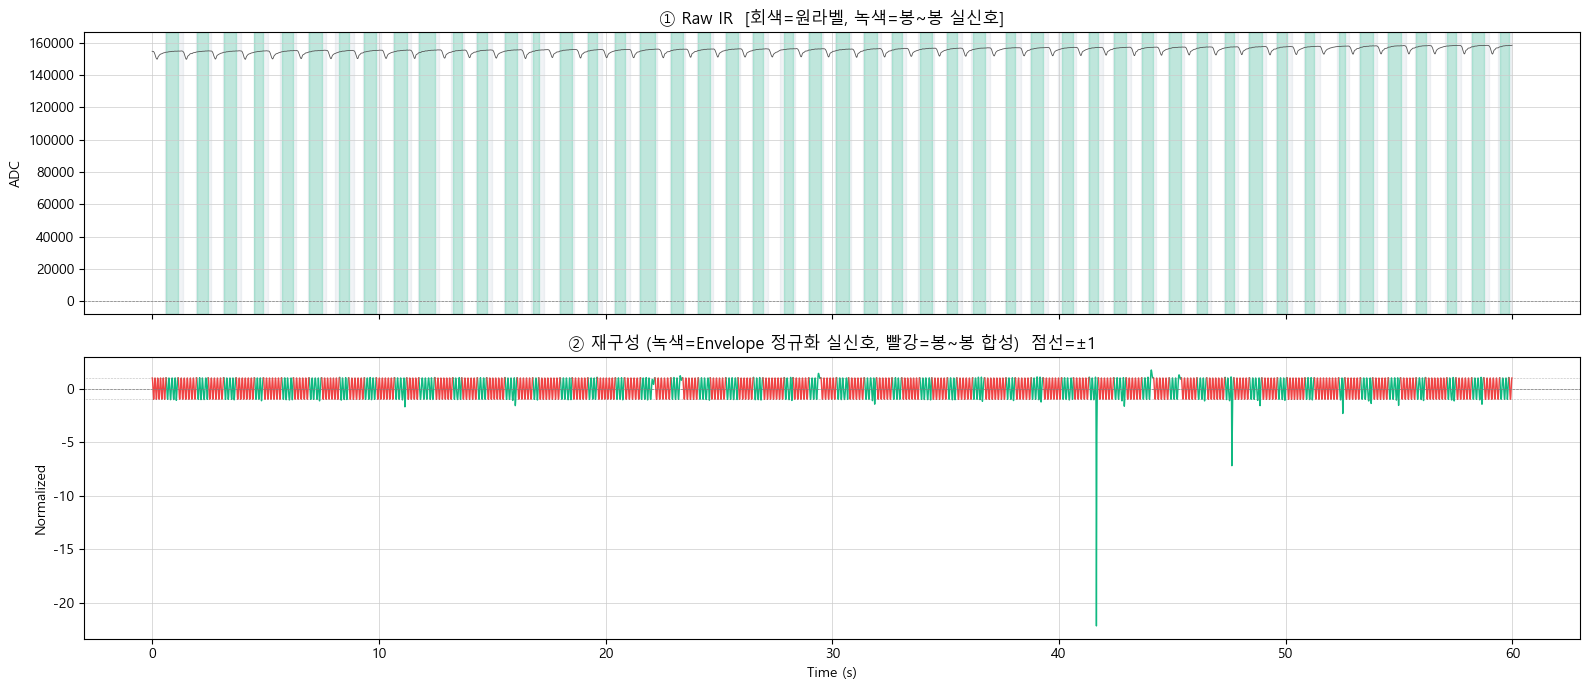

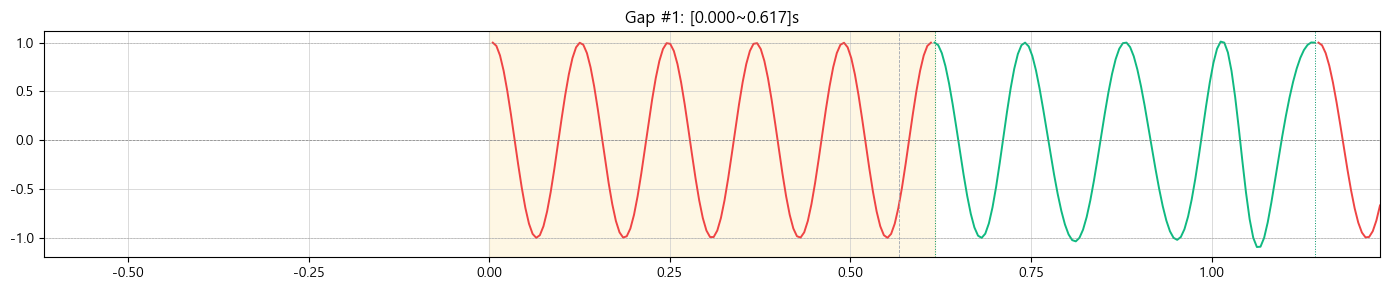

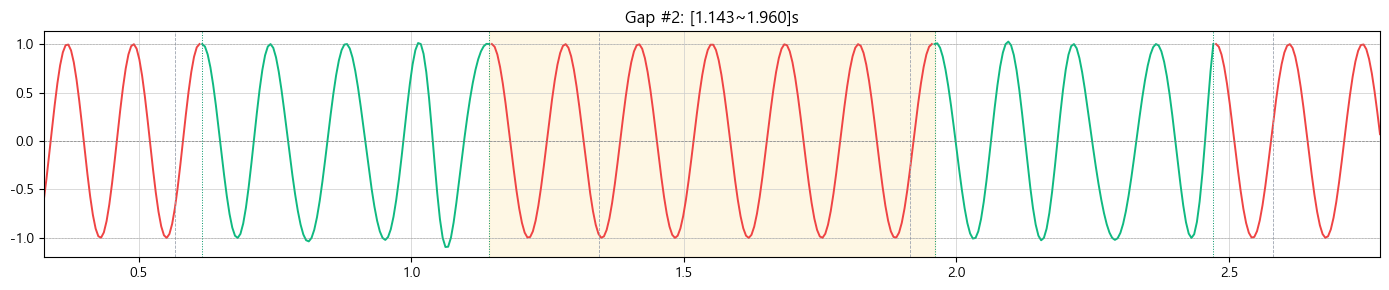

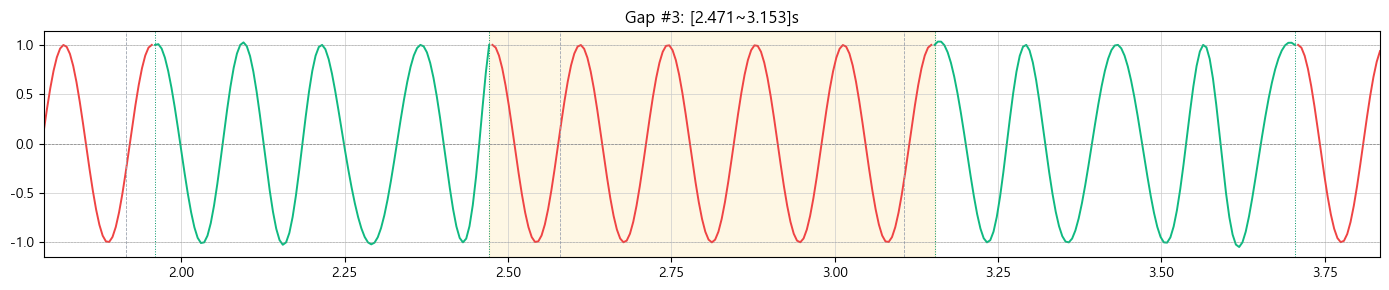

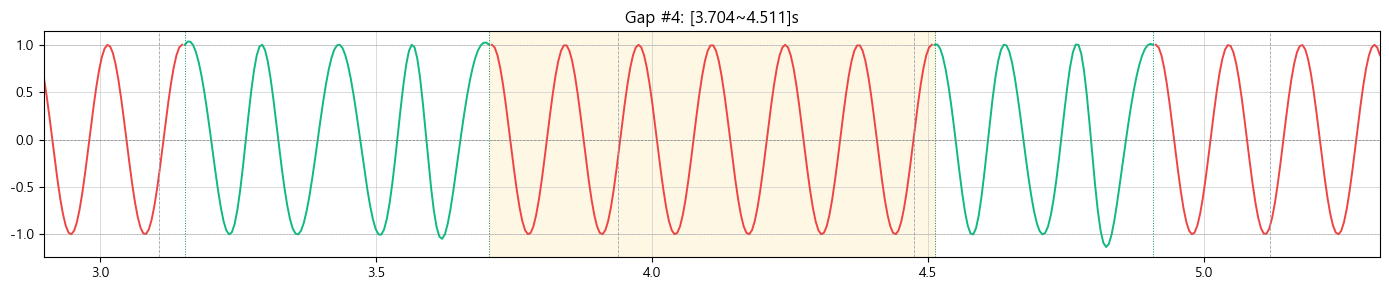

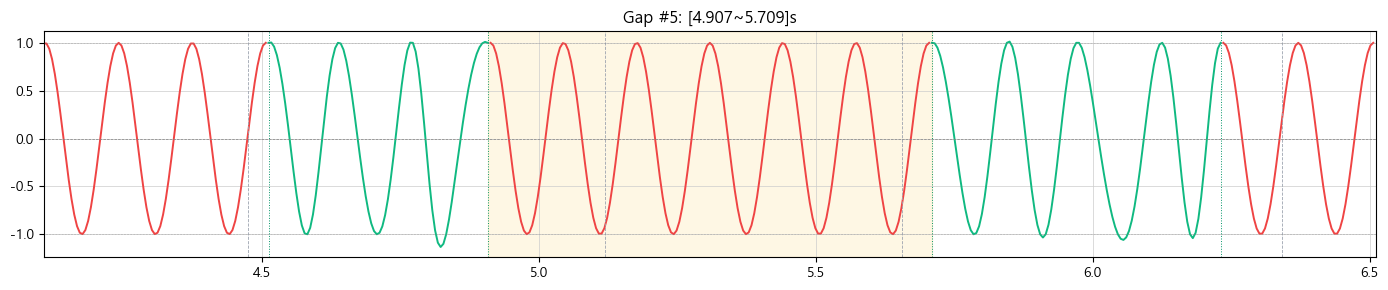

In [9]:
# === v4: 봉~봉 영역 + Envelope 정규화 — 단일 셀 ===
import os, platform
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import CubicSpline

if platform.system() == "Windows":
    matplotlib.rc("font", family="Malgun Gothic")
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 설정 ──
DATA_FOLDER = r"data\ppg_raw\20260507_162235"
PAD_SEC     = 0.3
MA_WIN_SEC  = 0.15
BPF_LO, BPF_HI, BPF_ORDER = 3.0, 12.0, 4
PEAK_MIN_DIST_SEC = 0.08
PEAK_PROM_FACTOR  = 0.3

# ── 데이터 로드 ──
df = pd.read_csv(os.path.join(DATA_FOLDER, "ppg_sensor.csv")).dropna().reset_index(drop=True)
timestamps = df["Timestamp"].values.astype(float)
sig_raw    = df["IR_Value_Raw"].values.astype(float)
dt = float(np.median(np.diff(timestamps))); fs = int(round(1.0 / dt))
t  = timestamps - timestamps[0]
labels = pd.read_csv(os.path.join(DATA_FOLDER, "hr_segments.csv")).sort_values('start_time').reset_index(drop=True)
print(f"fs={fs}Hz, length={t[-1]:.2f}s, labels={len(labels)}")

# ── 격리 처리 ──
def process_isolated(s, e):
    t0 = max(0.0, s - PAD_SEC); t1 = min(float(t[-1]), e + PAD_SEC)
    m = (t >= t0) & (t <= t1)
    t_ext, raw_ext = t[m], sig_raw[m].astype(float)
    if len(raw_ext) < 10: return t_ext, raw_ext - raw_ext.mean()
    ma_win = max(3, min(int(MA_WIN_SEC * fs), len(raw_ext) // 3))
    detrended = raw_ext - uniform_filter1d(raw_ext, size=ma_win)
    nyq = fs / 2.0
    b, a = butter(BPF_ORDER, [BPF_LO/nyq, min(BPF_HI, nyq*0.98)/nyq], btype='band')
    return t_ext, filtfilt(b, a, detrended, padlen=min(3*max(len(a),len(b)), len(detrended)-1))

# ── Envelope 정규화 ──
def envelope_normalize(t_real, sig_real, t_pk, v_pk, t_vl, v_vl, t_lo_b, t_hi_b):
    """봉/곶 cubic spline envelope로 정규화: 모든 봉=+1, 모든 곶=-1"""
    # 위 envelope: 봉들을 지나는 spline (real 영역 양 끝이 봉이므로 외삽 불필요)
    if len(t_pk) >= 2:
        try:    upper = CubicSpline(t_pk, v_pk, bc_type='natural', extrapolate=True)(t_real)
        except Exception: upper = np.interp(t_real, t_pk, v_pk)
    else:
        upper = np.full_like(sig_real, float(v_pk[0]))

    # 아래 envelope: 곶들 + 양끝 padding (첫/마지막 곶 값으로 고정 → 외삽 안정화)
    if len(t_vl) >= 1:
        t_lp = np.concatenate([[t_lo_b], t_vl, [t_hi_b]])
        v_lp = np.concatenate([[v_vl[0]], v_vl, [v_vl[-1]]])
        # 시간 중복 제거
        order = np.argsort(t_lp); t_lp, v_lp = t_lp[order], v_lp[order]
        keep = np.concatenate([[True], np.diff(t_lp) > 1e-9])
        t_lp, v_lp = t_lp[keep], v_lp[keep]
        if len(t_lp) >= 2:
            try:    lower = CubicSpline(t_lp, v_lp, bc_type='natural', extrapolate=True)(t_real)
            except Exception: lower = np.interp(t_real, t_lp, v_lp)
        else:
            lower = np.full_like(sig_real, float(v_lp[0]))
    else:
        lower = np.full_like(sig_real, float(sig_real.min()))

    diff = upper - lower
    diff = np.where(np.abs(diff) < 1e-9, 1.0, diff)
    return 2.0 * (sig_real - lower) / diff - 1.0

# ── 라벨 처리 ──
segments = []; skipped = []
for i, row in labels.iterrows():
    s, e = float(row['start_time']), float(row['end_time'])
    t_ext, sig_ext = process_isolated(s, e)
    label_m = (t_ext >= s) & (t_ext <= e)
    if np.sum(label_m) < 4:
        skipped.append((i, "too short")); continue
    sig_label = sig_ext[label_m]; t_label = t_ext[label_m]

    min_d = max(2, int(PEAK_MIN_DIST_SEC * fs))
    if sig_label.std() < 1e-9:
        skipped.append((i, "flat")); continue
    prom = sig_label.std() * PEAK_PROM_FACTOR
    pks, _ = find_peaks( sig_label, distance=min_d, prominence=prom)
    vls, _ = find_peaks(-sig_label, distance=min_d, prominence=prom)
    if len(pks) < 2:
        skipped.append((i, f"peaks<2 ({len(pks)})")); continue

    t_pk = t_label[pks]; v_pk = sig_label[pks]
    t_vl = t_label[vls] if len(vls) > 0 else np.array([])
    v_vl = sig_label[vls] if len(vls) > 0 else np.array([])

    first_peak_t = float(t_pk[0]); last_peak_t = float(t_pk[-1])
    real_m = (t_ext >= first_peak_t) & (t_ext <= last_peak_t)
    t_real, sig_real = t_ext[real_m], sig_ext[real_m]

    sig_norm = envelope_normalize(t_real, sig_real, t_pk, v_pk, t_vl, v_vl,
                                   first_peak_t, last_peak_t)

    global_m = (t >= first_peak_t) & (t <= last_peak_t)
    L = min(np.sum(global_m), len(sig_norm))
    gidx = np.where(global_m)[0][:L]
    gm = np.zeros_like(global_m); gm[gidx] = True

    period = float(np.median(np.diff(t_pk)))
    segments.append({
        'orig_start': s, 'orig_end': e,
        'start': first_peak_t, 'end': last_peak_t,
        'mask': gm, 't_seg': t_real[:L], 'sig_seg': sig_norm[:L],
        'period': period,
    })

print(f"\n사용된 구간: {len(segments)}/{len(labels)}  (스킵 {len(skipped)}개)")
for i, reason in skipped[:5]: print(f"  - 라벨 #{i+1}: {reason}")
periods = [s['period'] for s in segments]
global_T = float(np.median(periods)) if periods else 0.15
print(f"전역 주기: {global_T*1000:.1f}ms ({60/global_T:.1f} BPM)")
print(f"정규화 후 실신호 범위: [{min(s['sig_seg'].min() for s in segments):+.2f}, "
      f"{max(s['sig_seg'].max() for s in segments):+.2f}]  (이상적: [-1, +1])")

# ── 봉~봉 합성 (v3과 동일) ──
def gen_pp_synth(t_gap, T_ref, peak_s, peak_e, valley_ref=-1.0):
    n = len(t_gap)
    if n < 2 or T_ref is None or T_ref <= 0:
        return np.linspace(peak_s, peak_e, n), 0.0, 0
    dur = float(t_gap[-1] - t_gap[0])
    if dur < T_ref * 0.5:
        return np.linspace(peak_s, peak_e, n), dur, 0
    n_cyc = max(1, int(round(dur / T_ref)))
    adj_T = dur / n_cyc
    phase = 2 * np.pi * (t_gap - t_gap[0]) / adj_T
    p = (t_gap - t_gap[0]) / dur
    peak_t = peak_s * (1 - p) + peak_e * p
    return (peak_t + valley_ref)/2 + (peak_t - valley_ref)/2 * np.cos(phase), adj_T, n_cyc

# ── 재구성 ──
sig_recon = np.zeros_like(sig_raw, dtype=float)
is_synth  = np.zeros_like(sig_raw, dtype=bool)
filled    = np.zeros_like(sig_raw, dtype=bool)
for seg in segments:
    sig_recon[seg['mask']] = seg['sig_seg']; filled[seg['mask']] = True

gaps = []
if segments:
    if segments[0]['start'] > t[0] + 1e-9: gaps.append((t[0], segments[0]['start'], None, segments[0]))
    for i in range(len(segments)-1):
        gaps.append((segments[i]['end'], segments[i+1]['start'], segments[i], segments[i+1]))
    if segments[-1]['end'] < t[-1] - 1e-9: gaps.append((segments[-1]['end'], t[-1], segments[-1], None))

print(f"\n갭 보간 ({len(gaps)}개):")
for gs, ge, ps, ns in gaps:
    gm = (t > gs) & (t < ge) & (~filled)
    if not np.any(gm): continue
    t_gap = t[gm]
    Ts = [x['period'] for x in (ps,ns) if x and x.get('period')]
    T_ref = float(np.median(Ts)) if Ts else global_T
    peak_s = ps['sig_seg'][-1] if ps else (ns['sig_seg'][0] if ns else 1.0)
    peak_e = ns['sig_seg'][0]  if ns else (ps['sig_seg'][-1] if ps else 1.0)
    synth, adj_T, n_cyc = gen_pp_synth(t_gap, T_ref, peak_s, peak_e, -1.0)
    sig_recon[gm] = synth; is_synth[gm] = True

# ── 시각화 (NaN으로 끊어 분리) ──
sig_real_plot  = np.where(filled,   sig_recon, np.nan)
sig_synth_plot = np.where(is_synth, sig_recon, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True, facecolor='white')
axes[0].plot(t, sig_raw, color='#555', lw=0.6)
for seg in segments:
    axes[0].axvspan(seg['orig_start'], seg['orig_end'], color='#94a3b8', alpha=0.12)
    axes[0].axvspan(seg['start'], seg['end'], color='#10b981', alpha=0.22)
axes[0].set_title("① Raw IR  [회색=원라벨, 녹색=봉~봉 실신호]"); axes[0].set_ylabel("ADC")

axes[1].plot(t, sig_real_plot,  color='#10b981', lw=1.0)
axes[1].plot(t, sig_synth_plot, color='#ef4444', lw=1.0)
axes[1].axhline( 1, color='gray', lw=0.4, ls=':')
axes[1].axhline(-1, color='gray', lw=0.4, ls=':')
axes[1].set_title("② 재구성 (녹색=Envelope 정규화 실신호, 빨강=봉~봉 합성)  점선=±1")
axes[1].set_ylabel("Normalized"); axes[1].set_xlabel("Time (s)")
for ax in axes: ax.grid(True, color='#ccc', lw=0.5); ax.axhline(0, color='gray', lw=0.5, ls='--')
plt.tight_layout(); plt.show()

# ── Gap 줌인 ──
for gi, (gs, ge, ps, ns) in enumerate(gaps[:5]):
    pad = max(0.3, ge - gs); x0, x1 = gs - pad, ge + pad
    m_zoom = (t >= x0) & (t <= x1)

    fig, ax = plt.subplots(figsize=(14, 3), facecolor='white')
    ax.plot(t[m_zoom], sig_real_plot[m_zoom],  color='#10b981', lw=1.4)
    ax.plot(t[m_zoom], sig_synth_plot[m_zoom], color='#ef4444', lw=1.4)
    for seg in segments:
        if seg['t_seg'][-1] < x0 or seg['t_seg'][0] > x1: continue
        if x0 <= seg['orig_start'] <= x1: ax.axvline(seg['orig_start'], color='#9ca3af', lw=0.6, ls='--')
        if x0 <= seg['orig_end']   <= x1: ax.axvline(seg['orig_end'],   color='#9ca3af', lw=0.6, ls='--')
        if x0 <= seg['start'] <= x1: ax.axvline(seg['start'], color='#059669', lw=0.7, ls=':')
        if x0 <= seg['end']   <= x1: ax.axvline(seg['end'],   color='#059669', lw=0.7, ls=':')
    ax.axvspan(gs, ge, color='#fbbf24', alpha=0.12)
    ax.axhline( 1, color='gray', lw=0.4, ls=':'); ax.axhline(-1, color='gray', lw=0.4, ls=':')
    ax.set_xlim(x0, x1); ax.grid(True, color='#ccc', lw=0.5); ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_title(f"Gap #{gi+1}: [{gs:.3f}~{ge:.3f}]s")
    plt.tight_layout(); plt.show()


원신호와 비교

fs=199.5 Hz  duration=60.0s  segments=49
유효 세그먼트: 49 / 49
갭 수: 48


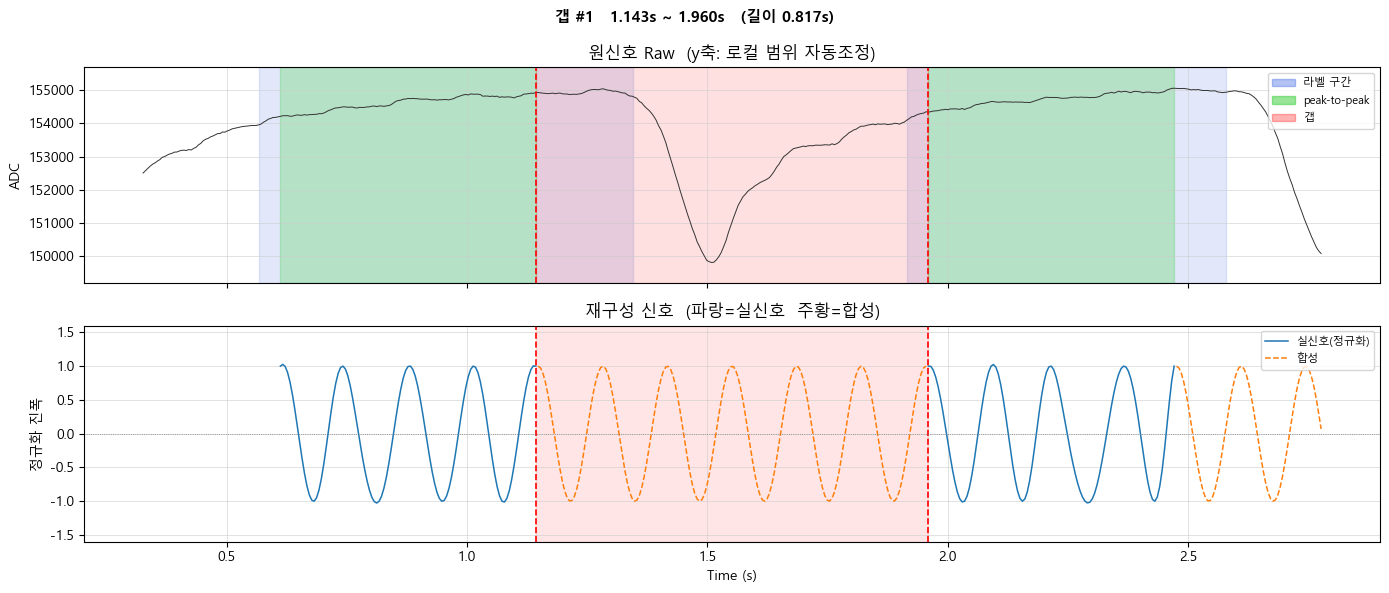

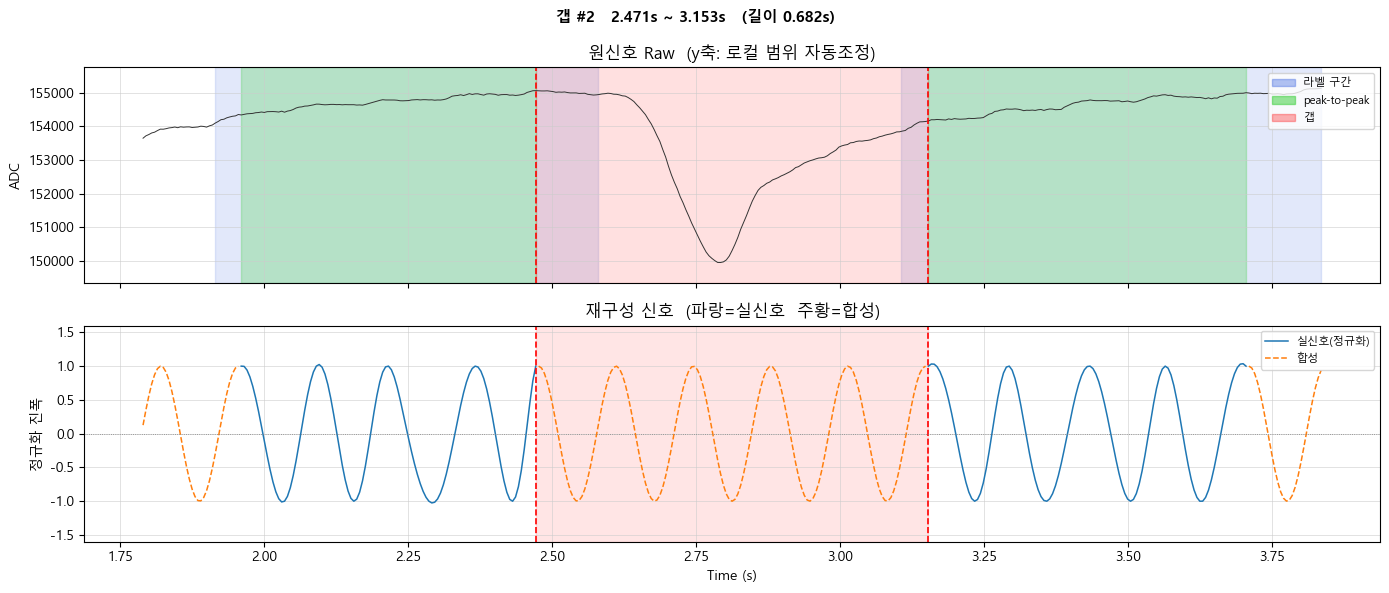

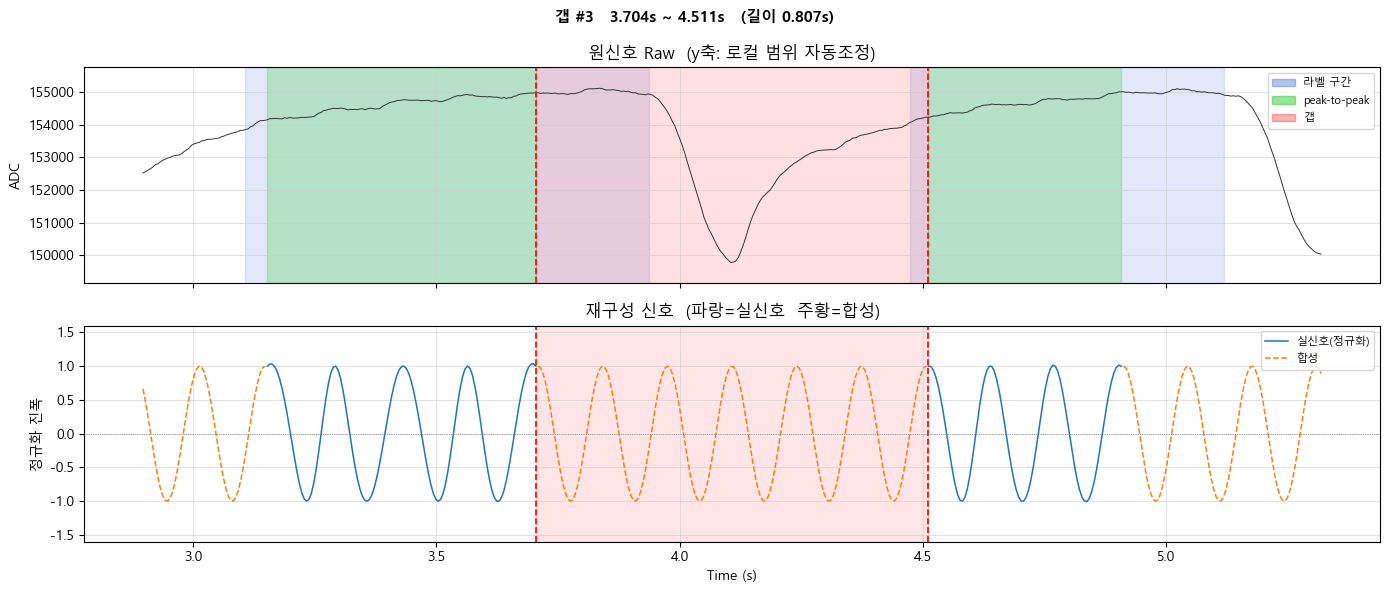

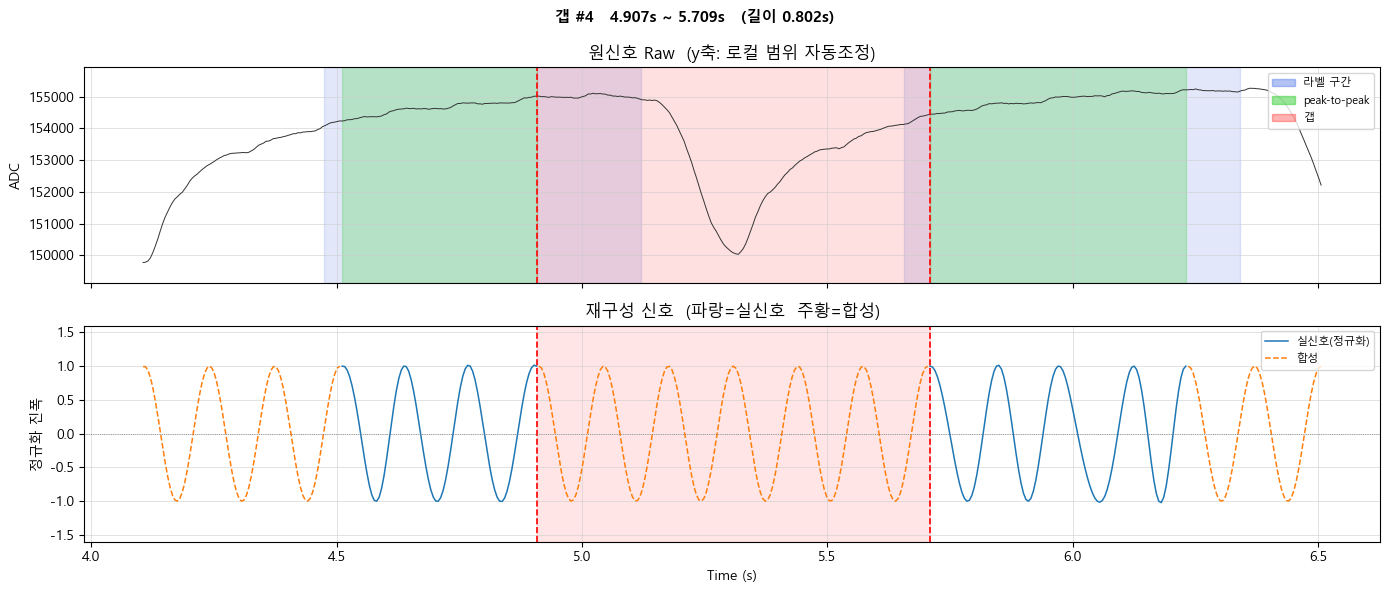

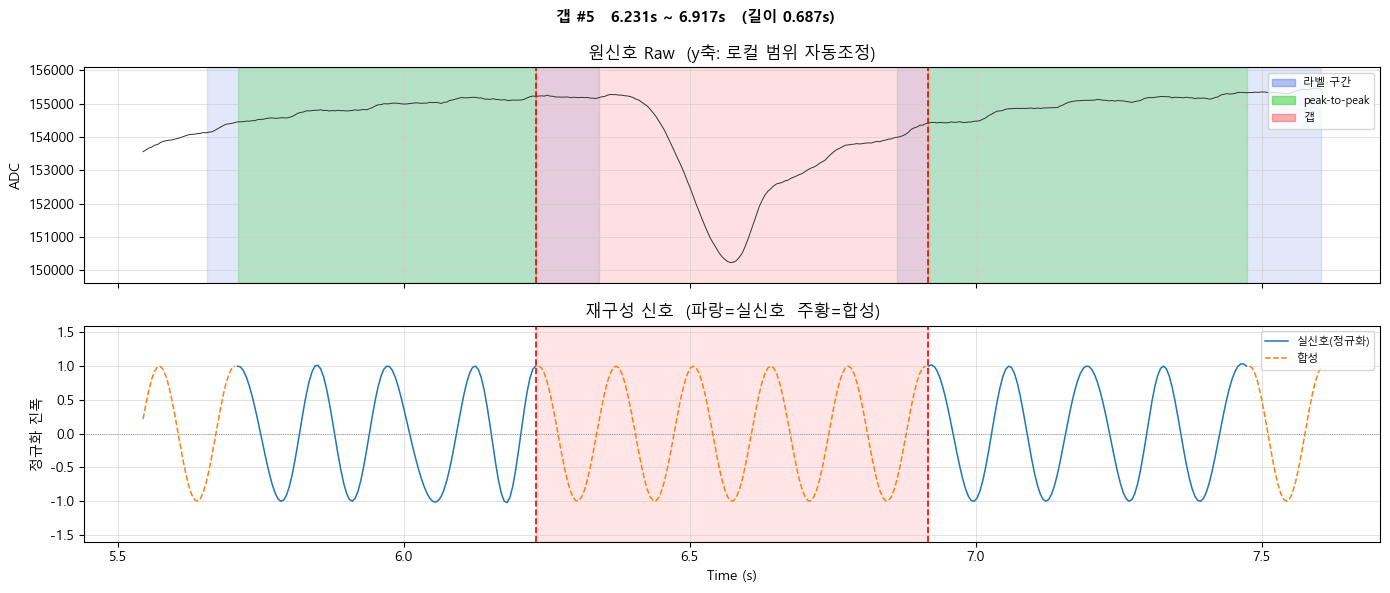

In [11]:
# ============================================================
#  PPG 재구성 + 갭 비교 시각화  (독립 실행 가능)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt, platform
from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import CubicSpline

if platform.system() == "Windows":  matplotlib.rc("font", family="Malgun Gothic")
elif platform.system() == "Darwin": matplotlib.rc("font", family="AppleGothic")
else:                               matplotlib.rc("font", family="NanumGothic")
matplotlib.rcParams["axes.unicode_minus"] = False

# ── 설정 ─────────────────────────────────────────────────────
BASE_DIR   = r"data\ppg_raw\20260507_162235"
PPG_CSV    = BASE_DIR + r"\ppg_sensor.csv"
LABEL_CSV  = BASE_DIR + r"\hr_segments.csv"

PAD_SEC    = 0.30   # 고립 처리 패딩 (초)
MA_WIN_SEC = 0.15   # 이동평균 창 (초)
BPF_LO     = 3.0   # BPF 하한 (Hz)
BPF_HI     = 12.0  # BPF 상한 (Hz)
BPF_ORDER  = 4
PEAK_PROM  = 0.3   # prominence = std * 이 값
N_GAPS     = 5     # 시각화할 갭 수

# ── 데이터 로드 ───────────────────────────────────────────────
df       = pd.read_csv(PPG_CSV).dropna()
sig_raw  = df["IR_Value_Raw"].values.astype(float)
t        = df["Timestamp"].values - df["Timestamp"].values[0]
dt       = np.median(np.diff(t))
fs       = 1.0 / dt
labels   = pd.read_csv(LABEL_CSV)
print(f"fs={fs:.1f} Hz  duration={t[-1]:.1f}s  segments={len(labels)}")

# ── 처리 함수 ─────────────────────────────────────────────────
def _bpf(sig):
    nyq  = fs / 2
    hi   = min(BPF_HI, nyq * 0.98)
    b, a = butter(BPF_ORDER, [BPF_LO / nyq, hi / nyq], btype='band')
    return filtfilt(b, a, sig)

def process_isolated(s, e):
    s_pad = max(t[0], s - PAD_SEC)
    e_pad = min(t[-1], e + PAD_SEC)
    m     = (t >= s_pad) & (t <= e_pad)
    t_e, s_e = t[m], sig_raw[m].copy()
    ma_n  = max(3, int(MA_WIN_SEC * fs))
    s_dt  = s_e - uniform_filter1d(s_e, ma_n)
    s_bf  = _bpf(s_dt)
    inner = (t_e >= s) & (t_e <= e)
    return t_e[inner], s_bf[inner]

def detect(t_s, s_s):
    min_d = max(2, int(0.05 * fs))
    prom  = s_s.std() * PEAK_PROM
    pk, _ = find_peaks( s_s, distance=min_d, prominence=prom)
    vl, _ = find_peaks(-s_s, distance=min_d, prominence=prom)
    return pk, vl

def envelope_norm(t_r, s_r, t_pk, s_pk, t_vl, s_vl):
    cs_up = CubicSpline(t_pk, s_pk, bc_type='natural')
    upper = cs_up(t_r)
    # 하한: 끝단 앵커 패딩
    t_lb  = np.concatenate([[t_r[0]], t_vl, [t_r[-1]]])
    s_lb  = np.concatenate([[s_vl[0]], s_vl, [s_vl[-1]]])
    _, ui = np.unique(t_lb, return_index=True)
    cs_lo = CubicSpline(t_lb[ui], s_lb[ui], bc_type='natural')
    lower = cs_lo(t_r)
    denom = np.where(upper - lower < 1e-9, 1e-9, upper - lower)
    return 2.0 * (s_r - lower) / denom - 1.0

def gen_synth(t_gap, T_ref, valley_ref=-1.0):
    n_cyc = max(1, round((t_gap[-1] - t_gap[0]) / T_ref))
    adj_T = (t_gap[-1] - t_gap[0]) / n_cyc
    phase = 2 * np.pi * (t_gap - t_gap[0]) / adj_T
    mid   = (1.0 + valley_ref) / 2
    amp   = (1.0 - valley_ref) / 2
    return mid + amp * np.cos(phase)

# ── 각 라벨 구간 처리 ─────────────────────────────────────────
segs = []
for _, row in labels.iterrows():
    s, e       = row["start_time"], row["end_time"]
    t_s, sig_s = process_isolated(s, e)
    if len(t_s) < 10:
        segs.append(None); continue

    pk, vl = detect(t_s, sig_s)
    if len(pk) < 2 or len(vl) < 1:
        segs.append(None); continue

    # peak-to-peak 실신호 구간
    t_lo, t_hi = t_s[pk[0]], t_s[pk[-1]]
    m_pp = (t_s >= t_lo) & (t_s <= t_hi)
    if m_pp.sum() < 5:
        segs.append(None); continue

    t_r, s_r  = t_s[m_pp], sig_s[m_pp]
    pk_r = pk[(t_s[pk] >= t_lo) & (t_s[pk] <= t_hi)]
    vl_r = vl[(t_s[vl] >= t_lo) & (t_s[vl] <= t_hi)]
    if len(pk_r) < 2 or len(vl_r) < 1:
        segs.append(None); continue

    try:
        sig_norm = envelope_norm(t_r, s_r,
                                 t_s[pk_r], sig_s[pk_r],
                                 t_s[vl_r], sig_s[vl_r])
    except Exception as ex:
        print(f"  normalize 실패: {ex}"); segs.append(None); continue

    segs.append({"t": t_r, "sig": sig_norm,
                 "period": np.median(np.diff(t_s[pk_r])),
                 "t_s": t_lo, "t_e": t_hi})

valid = [s for s in segs if s is not None]
print(f"유효 세그먼트: {len(valid)} / {len(labels)}")

# ── 재구성 배열 ───────────────────────────────────────────────
sig_rc = np.full(len(t), np.nan)
filled = np.zeros(len(t), bool)
is_syn = np.zeros(len(t), bool)

for seg in valid:
    m = (t >= seg["t_s"]) & (t <= seg["t_e"])
    sig_rc[m] = np.interp(t[m], seg["t"], seg["sig"])
    filled[m] = True

for i in range(len(valid) - 1):
    a, b   = valid[i], valid[i + 1]
    gs, ge = a["t_e"], b["t_s"]
    if ge <= gs: continue
    T_ref  = (a["period"] + b["period"]) / 2
    m_gap  = (t > gs) & (t < ge)
    if m_gap.sum() < 2: continue
    sig_rc[m_gap] = gen_synth(t[m_gap], T_ref)
    filled[m_gap] = True
    is_syn[m_gap] = True

# NaN 마스킹 (연결선 방지)
sig_rp = np.where(filled & ~is_syn, sig_rc, np.nan)
sig_sp = np.where(is_syn,           sig_rc, np.nan)

# ── 갭 목록 ───────────────────────────────────────────────────
gaps = [(valid[i]["t_e"], valid[i + 1]["t_s"], valid[i], valid[i + 1])
        for i in range(len(valid) - 1)
        if valid[i + 1]["t_s"] > valid[i]["t_e"]]
print(f"갭 수: {len(gaps)}")

# ── 갭 줌 비교 시각화 ─────────────────────────────────────────
for gi, (gs, ge, seg_a, seg_b) in enumerate(gaps[:N_GAPS]):
    pad = max(0.3, ge - gs)
    x0, x1 = gs - pad, ge + pad
    m   = (t >= x0) & (t <= x1)

    fig, (ax_r, ax_rc) = plt.subplots(
        2, 1, figsize=(14, 6), sharex=True,
        gridspec_kw={'height_ratios': [1, 1]})
    fig.suptitle(
        f"갭 #{gi+1}   {gs:.3f}s ~ {ge:.3f}s   (길이 {ge-gs:.3f}s)",
        fontsize=11, fontweight='bold')

    # ── 상단: 원신호 Raw ──────────────────────────────────────
    raw_win = sig_raw[m]
    y_lo, y_hi = raw_win.min(), raw_win.max()
    margin = max((y_hi - y_lo) * 0.12, 1.0)

    ax_r.plot(t[m], raw_win, color='#333333', lw=0.7, label='Raw IR')
    ax_r.set_ylim(y_lo - margin, y_hi + margin)   # ★ DC 오프셋 해결: 로컬 범위로 y축 제한

    # 라벨 구간 (파랑)
    for _, row in labels.iterrows():
        if row["end_time"] < x0 or row["start_time"] > x1: continue
        ax_r.axvspan(max(row["start_time"], x0), min(row["end_time"], x1),
                     alpha=0.15, color='royalblue')
    # peak-to-peak 실구간 (초록)
    for seg in valid:
        if seg["t_e"] < x0 or seg["t_s"] > x1: continue
        ax_r.axvspan(max(seg["t_s"], x0), min(seg["t_e"], x1),
                     alpha=0.25, color='limegreen')
    # 갭 영역 (빨강)
    ax_r.axvspan(gs, ge, alpha=0.12, color='red', label='갭')
    ax_r.axvline(gs, color='red', lw=1.2, ls='--')
    ax_r.axvline(ge, color='red', lw=1.2, ls='--')

    from matplotlib.patches import Patch
    ax_r.legend(handles=[
        Patch(color='royalblue', alpha=0.4, label='라벨 구간'),
        Patch(color='limegreen', alpha=0.5, label='peak-to-peak'),
        Patch(color='red',       alpha=0.3, label='갭'),
    ], fontsize=8, loc='upper right')
    ax_r.set_ylabel("ADC")
    ax_r.set_title("원신호 Raw  (y축: 로컬 범위 자동조정)")
    ax_r.grid(True, color='#cccccc', lw=0.4)

    # ── 하단: 재구성 신호 ─────────────────────────────────────
    ax_rc.plot(t[m], sig_rp[m], color='#1f77b4', lw=1.1, label='실신호(정규화)')
    ax_rc.plot(t[m], sig_sp[m], color='#ff7f0e', lw=1.1, ls='--', label='합성')
    ax_rc.axvspan(gs, ge, alpha=0.10, color='red')
    ax_rc.axvline(gs, color='red', lw=1.2, ls='--')
    ax_rc.axvline(ge, color='red', lw=1.2, ls='--')
    ax_rc.axhline(0,  color='gray', lw=0.6, ls=':')
    ax_rc.set_ylim(-1.6, 1.6)
    ax_rc.set_ylabel("정규화 진폭")
    ax_rc.set_xlabel("Time (s)")
    ax_rc.legend(fontsize=8, loc='upper right')
    ax_rc.set_title("재구성 신호  (파랑=실신호  주황=합성)")
    ax_rc.grid(True, color='#cccccc', lw=0.4)

    plt.tight_layout()
    plt.show()
